In [ ]:
#Step 1 — Load and Inspect the Raw Dataset
#We will:
#Import the required libraries.
#Load the CSV file.
#Check the number of rows and columns.
#Display column names.
#Preview the first few records.
#Check the data types of all columns.
#Identify missing values.
#Identify duplicate records.
import pandas as pd
import numpy as np
print("libraries imported succesfully")

libraries imported succesfully


In [ ]:
df=pd.read_csv("task4_retail_sales_raw.csv")
print("database loaded successfully")
print("rows:",df.shape[0])
print("column:",df.shape[1])

database loaded successfully
rows: 125
column: 13


In [ ]:
df.head()

,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,ELECTRONICS,Wireless Mouse,6.0,NaN,0,cash,online,completed
1,O0002,04-25-2026,C004,Neha Singh,Jabalpur,Electronics,Headphones,1.0,1400.0,15,cod,offline,completed
2,O0003,06-04-2026,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,Offline,Pending
3,O0004,02-28-2026,C005,rohit patel,Ujjain,Grocery,Cooking Oil,1.0,160.0,0,upi,Online,cancelled
4,O0005,12/06/2026,C003,AMIT KHAN,Rewa,Grocery,Rice Bag,5.0,950.0,5,cash,Online,Cancelled


#Step 2 — Perform a Data Quality Audit
#We will systematically identify problems in the raw dataset.
#We will check:
#Missing values
#Duplicate rows
#Incorrect data types
#Inconsistent categorical values
#Extra spaces
#Different capitalization
#Invalid or inconsistent dates
#Numeric values stored as text
#Possible invalid values or outliers
#Purpose: Create evidence of what needs to be transformed.

In [ ]:
df.shape

(125, 13)

In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
city,3
category,0
product,0
quantity,2
unit_price,7
discount_pct,0


In [ ]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df.dtypes

,0
order_id,object
order_date,object
customer_id,object
customer_name,object
city,object
category,object
product,object
quantity,float64
unit_price,float64
discount_pct,int64


In [ ]:
df.select_dtypes(include="object").columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'city',
       'category', 'product', 'payment_method', 'sales_channel', 'status'],
      dtype='object')

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- order_id ---
order_id
O0005    2
O0045    2
O0056    2
O0027    2
O0048    2
        ..
O0116    1
O0117    1
O0118    1
O0119    1
O0120    1
Name: count, Length: 120, dtype: int64

--- order_date ---
order_date
12/06/2026     2
12/05/2026     2
13/05/2026     2
30-Mar-2026    2
03-05-2026     2
              ..
2026-01-18     1
27/03/2026     1
02-18-2026     1
05-08-2026     1
03-17-2026     1
Name: count, Length: 112, dtype: int64

--- customer_id ---
customer_id
C011    14
C007    14
C012    13
C002    12
C010    11
C001    11
C006    10
C008     9
C009     9
C003     8
C005     7
C004     7
Name: count, dtype: int64

--- customer_name ---
customer_name
Vikas Tiwari      14
Arjun Mehta       14
Meena Joshi       13
  Priya Verma     12
  Anjali Rao      11
Rahul Sharma      11
Sneha Gupta       10
Pooja Yadav        9
Karan Jain         9
AMIT KHAN          8
rohit patel        7
Neha Singh         7
Name: count, dtype: int64

--- city ---
city
Bhopal      34
Indore      25
U

In [ ]:
for col in df.select_dtypes(include='object').columns:
    spaces = df[col].astype(str).str.strip() != df[col].astype(str)
    print(col, "->", spaces.sum(), "values with extra spaces")

order_id -> 0 values with extra spaces
order_date -> 0 values with extra spaces
customer_id -> 0 values with extra spaces
customer_name -> 30 values with extra spaces
city -> 0 values with extra spaces
category -> 38 values with extra spaces
product -> 0 values with extra spaces
payment_method -> 13 values with extra spaces
sales_channel -> 26 values with extra spaces
status -> 19 values with extra spaces


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print("\n---", col, "---")
    print(df[col].dropna().astype(str).str.lower().value_counts())


--- order_id ---
order_id
o0005    2
o0045    2
o0056    2
o0027    2
o0048    2
        ..
o0116    1
o0117    1
o0118    1
o0119    1
o0120    1
Name: count, Length: 120, dtype: int64

--- order_date ---
order_date
12/06/2026     2
12/05/2026     2
13/05/2026     2
30-mar-2026    2
03-05-2026     2
              ..
2026-01-18     1
27/03/2026     1
02-18-2026     1
05-08-2026     1
03-17-2026     1
Name: count, Length: 112, dtype: int64

--- customer_id ---
customer_id
c011    14
c007    14
c012    13
c002    12
c010    11
c001    11
c006    10
c008     9
c009     9
c003     8
c005     7
c004     7
Name: count, dtype: int64

--- customer_name ---
customer_name
vikas tiwari      14
arjun mehta       14
meena joshi       13
  priya verma     12
  anjali rao      11
rahul sharma      11
sneha gupta       10
pooja yadav        9
karan jain         9
amit khan          8
rohit patel        7
neha singh         7
Name: count, dtype: int64

--- city ---
city
bhopal      34
indore      25
u

In [ ]:
for col in df.columns:
   if   'date' in col.lower() or 'time' in col.lower():
         print(col)

order_date


In [ ]:
for col in df.columns:
   if df[col].dtype == 'object':
     print("\n---",col,"---")
     print(df[col].head())


--- order_id ---
0    O0001
1    O0002
2    O0003
3    O0004
4    O0005
Name: order_id, dtype: object

--- order_date ---
0    2026-02-05
1    04-25-2026
2    06-04-2026
3    02-28-2026
4    12/06/2026
Name: order_date, dtype: object

--- customer_id ---
0    C011
1    C004
2    C006
3    C005
4    C003
Name: customer_id, dtype: object

--- customer_name ---
0    Vikas Tiwari
1     Neha Singh 
2     Sneha Gupta
3     rohit patel
4       AMIT KHAN
Name: customer_name, dtype: object

--- city ---
0      Ujjain
1    Jabalpur
2      Bhopal
3      Ujjain
4        Rewa
Name: city, dtype: object

--- category ---
0     ELECTRONICS 
1      Electronics
2      electronics
3          Grocery
4          Grocery
Name: category, dtype: object

--- product ---
0    Wireless Mouse
1        Headphones
2    Wireless Mouse
3       Cooking Oil
4          Rice Bag
Name: product, dtype: object

--- payment_method ---
0    cash
1     cod
2     upi
3     upi
4    cash
Name: payment_method, dtype: object

---

In [ ]:
df.describe()

,quantity,unit_price,discount_pct
count,123.000000,118.000000,125.000000
mean,3.463415,845.508475,9.360000
std,1.569654,440.556364,6.779238
min,1.000000,160.000000,0.000000
25%,2.000000,450.000000,5.000000
50%,3.000000,875.000000,10.000000
75%,5.000000,1150.000000,15.000000
max,6.000000,1700.000000,20.000000


In [ ]:
print("===== DATA QUALITY AUDIT SUMMARY =====")

print("\n1. Dataset Shape:")
print(df.shape)

print("\n2. Missing Values:")
print(df.isnull().sum())

print("\n3. Duplicate Rows:")
print(df.duplicated().sum())

print("\n4. Data Types:")
print(df.dtypes)

print("\n5. Numeric Summary:")
print(df.describe())

===== DATA QUALITY AUDIT SUMMARY =====

1. Dataset Shape:
(125, 13)

2. Missing Values:
order_id          0
order_date        0
customer_id       0
customer_name     0
city              3
category          0
product           0
quantity          2
unit_price        7
discount_pct      0
payment_method    0
sales_channel     0
status            0
dtype: int64

3. Duplicate Rows:
5

4. Data Types:
order_id           object
order_date         object
customer_id        object
customer_name      object
city               object
category           object
product            object
quantity          float64
unit_price        float64
discount_pct        int64
payment_method     object
sales_channel      object
status             object
dtype: object

5. Numeric Summary:
         quantity   unit_price  discount_pct
count  123.000000   118.000000    125.000000
mean     3.463415   845.508475      9.360000
std      1.569654   440.556364      6.779238
min      1.000000   160.000000      0.000000
25%

STEP 3 — Data Cleaning

Handle missing values
Remove duplicate rows
Convert order_date to datetime
Standardize categorical/text values
Check numeric columns
Re-check the cleaned dataset
Save the cleaned CSV

In [ ]:
df["city"].value_counts()

,count
city,
Bhopal,34
Indore,25
Ujjain,21
Jabalpur,18
Rewa,16
Satna,8


In [ ]:
city_mode =df["city"].mode([0])
print("most commun city:",city_mode)

most commun city: 0    Bhopal
Name: city, dtype: object


In [ ]:
df["city"] = df["city"].fillna(city_mode)

In [ ]:
df['city'].isnull().sum()

np.int64(3)

In [ ]:
df[df['city'].isna()][['order_id', 'customer_name', 'city']]

,order_id,customer_name,city
50,O0051,AMIT KHAN,NaN
77,O0078,Priya Verma,NaN
93,O0094,Karan Jain,NaN


In [ ]:
df['city'] = df['city'].fillna(df['city'].mode()[0])

In [ ]:
df['city'].isna().sum()

np.int64(0)

In [ ]:
quantity_median = df['quantity'].median()
print("Quantity Median:", quantity_median)

Quantity Median: 3.0


In [ ]:
df['quantity'] = df['quantity'].fillna(quantity_median)

In [ ]:
df['quantity'].isna().sum()

np.int64(0)

In [ ]:
unit_price_median = df['unit_price'].median()
print("Unit Price Median:", unit_price_median)

Unit Price Median: 875.0


In [ ]:
df['unit_price'] = df['unit_price'].fillna(unit_price_median)

In [ ]:
df['unit_price'].isna().sum()

np.int64(0)

In [ ]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (125, 13)


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("After removing duplicates:", df.shape)

After removing duplicates: (120, 13)


In [ ]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [ ]:
print(df['order_date'].head())

0    2026-02-05
1    04-25-2026
2    06-04-2026
3    02-28-2026
4    12/06/2026
Name: order_date, dtype: object


In [ ]:
print(df['order_date'].dtype)

object


In [ ]:
df['order_date'].head(10)

,order_date
0,2026-02-05
1,04-25-2026
2,06-04-2026
3,02-28-2026
4,12/06/2026
5,22-Mar-2026
6,05/02/2026
7,2026-01-13
8,06-14-2026
9,18/03/2026


In [ ]:
from datetime import datetime

def convert_date(value):
    formats = [
        "%Y-%m-%d",
        "%m-%d-%Y",
        "%m/%d/%Y",
        "%d/%m/%Y",
        "%d-%b-%Y"
    ]

    for fmt in formats:
        try:
            return datetime.strptime(str(value), fmt)
        except ValueError:
            continue

    return None

df['order_date'] = df['order_date'].apply(convert_date)

/tmp/ipykernel_471/3405964373.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = df['order_date'].apply(convert_date)


In [ ]:
print(df['order_date'].head(10))

0   2026-02-05
1   2026-04-25
2   2026-06-04
3   2026-02-28
4   2026-12-06
5   2026-03-22
6   2026-05-02
7   2026-01-13
8   2026-06-14
9   2026-03-18
Name: order_date, dtype: datetime64[ns]


In [ ]:
print(df['order_date'].dtype)

datetime64[ns]


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- order_id ---
order_id
O0001    1
O0002    1
O0003    1
O0004    1
O0005    1
        ..
O0116    1
O0117    1
O0118    1
O0119    1
O0120    1
Name: count, Length: 120, dtype: int64

--- customer_id ---
customer_id
C011    14
C007    13
C012    12
C010    11
C002    11
C001    11
C006    10
C008     9
C009     9
C004     7
C003     7
C005     6
Name: count, dtype: int64

--- customer_name ---
customer_name
Vikas Tiwari      14
Arjun Mehta       13
Meena Joshi       12
  Anjali Rao      11
  Priya Verma     11
Rahul Sharma      11
Sneha Gupta       10
Pooja Yadav        9
Karan Jain         9
Neha Singh         7
AMIT KHAN          7
rohit patel        6
Name: count, dtype: int64

--- city ---
city
Bhopal      36
Indore      23
Ujjain      20
Jabalpur    18
Rewa        15
Satna        8
Name: count, dtype: int64

--- category ---
category
Grocery          23
 ELECTRONICS     14
clothing         13
Home             10
Clothing          9
home              9
 HOME             8
elect

In [ ]:
categorical_cols = [
    'customer_name',
    'city',
    'category',
    'product',
    'payment_method',
    'sales_channel',
    'status'
]

for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

/tmp/ipykernel_471/2459635054.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].str.strip().str.title()


In [ ]:
for col in categorical_cols:
    print("\n---", col, "---")
    print(df[col].value_counts())


--- customer_name ---
customer_name
Vikas Tiwari    14
Arjun Mehta     13
Meena Joshi     12
Anjali Rao      11
Priya Verma     11
Rahul Sharma    11
Sneha Gupta     10
Pooja Yadav      9
Karan Jain       9
Neha Singh       7
Amit Khan        7
Rohit Patel      6
Name: count, dtype: int64

--- city ---
city
Bhopal      36
Indore      23
Ujjain      20
Jabalpur    18
Rewa        15
Satna        8
Name: count, dtype: int64

--- category ---
category
Grocery        36
Electronics    29
Clothing       28
Home           27
Name: count, dtype: int64

--- product ---
product
Tea Pack          14
Jeans             12
Water Bottle      12
Wireless Mouse    11
Cooking Oil       11
Rice Bag          11
Keyboard          10
Kurta              9
Headphones         8
Bedsheet           8
Lamp               7
T-Shirt            7
Name: count, dtype: int64

--- payment_method ---
payment_method
Upi     46
Cod     28
Cash    26
Card    20
Name: count, dtype: int64

--- sales_channel ---
sales_channel


In [ ]:
for col in categorical_cols:
    print("\n---", col, "---")
    print(df[col].value_counts())


--- customer_name ---
customer_name
Vikas Tiwari    14
Arjun Mehta     13
Meena Joshi     12
Anjali Rao      11
Priya Verma     11
Rahul Sharma    11
Sneha Gupta     10
Pooja Yadav      9
Karan Jain       9
Neha Singh       7
Amit Khan        7
Rohit Patel      6
Name: count, dtype: int64

--- city ---
city
Bhopal      36
Indore      23
Ujjain      20
Jabalpur    18
Rewa        15
Satna        8
Name: count, dtype: int64

--- category ---
category
Grocery        36
Electronics    29
Clothing       28
Home           27
Name: count, dtype: int64

--- product ---
product
Tea Pack          14
Jeans             12
Water Bottle      12
Wireless Mouse    11
Cooking Oil       11
Rice Bag          11
Keyboard          10
Kurta              9
Headphones         8
Bedsheet           8
Lamp               7
T-Shirt            7
Name: count, dtype: int64

--- payment_method ---
payment_method
Upi     46
Cod     28
Cash    26
Card    20
Name: count, dtype: int64

--- sales_channel ---
sales_channel


In [ ]:
numeric_cols = ['quantity', 'unit_price', 'discount_pct']

for col in numeric_cols:
    print("\n---", col, "---")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Negative values:", (df[col] < 0).sum())

TypeError: '<' not supported between instances of 'str' and 'int'

In [ ]:
print("Dataset Shape:", df.shape)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Data Types ---")
print(df.dtypes)

Dataset Shape: (120, 13)

--- Missing Values ---
order_id          0
order_date        0
customer_id       0
customer_name     0
city              0
category          0
product           0
quantity          0
unit_price        0
discount_pct      0
payment_method    0
sales_channel     0
status            0
dtype: int64

--- Duplicate Rows ---
0

--- Data Types ---
order_id                  object
order_date        datetime64[ns]
customer_id               object
customer_name             object
city                      object
category                  object
product                   object
quantity                 float64
unit_price               float64
discount_pct               int64
payment_method            object
sales_channel             object
status                    object
dtype: object


In [ ]:
df.to_csv("task4_cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


STEP 4 — Exploratory Data Analysis (EDA)

इसमें हम dataset से सवालों के जवाब निकालेंगे, जैसे:
Total sales कितनी हुई?
कौन-सी category सबसे ज्यादा बिक रही है?
कौन-सा product सबसे ज्यादा revenue दे रहा है?
कौन-सा city सबसे ज्यादा sales generate कर रहा है?
Online vs Offline sales कैसी हैं?
कौन-सा payment method ज्यादा इस्तेमाल हुआ?
Monthly sales trend क्या है?

अभी कोई code मत चलाइए।
पहले मैं Step 4 का पहला practical task दूँगा और साथ-साथ समझाऊँगा कि Data Analyst के रूप में हम यह analysis क्यों कर रहे हैं।

In [ ]:
df['gross_amount'] = df['quantity'] * df['unit_price']

df[['quantity', 'unit_price', 'gross_amount']].head()

/tmp/ipykernel_471/524510362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gross_amount'] = df['quantity'] * df['unit_price']


,quantity,unit_price,gross_amount
0,6.0,875.0,5250.0
1,1.0,1400.0,1400.0
2,1.0,700.0,700.0
3,1.0,160.0,160.0
4,5.0,950.0,4750.0


In [ ]:
df['discount_amount'] = (
    df['gross_amount'] * df['discount_pct'] / 100
)

df[['gross_amount', 'discount_pct', 'discount_amount']].head()

/tmp/ipykernel_471/1718883928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discount_amount'] = (


,gross_amount,discount_pct,discount_amount
0,5250.0,0,0.0
1,1400.0,15,210.0
2,700.0,20,140.0
3,160.0,0,0.0
4,4750.0,5,237.5


In [ ]:
df['sales_amount'] = df['gross_amount'] - df['discount_amount']

df[['gross_amount', 'discount_amount', 'sales_amount']].head()

/tmp/ipykernel_471/4262700632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sales_amount'] = df['gross_amount'] - df['discount_amount']


,gross_amount,discount_amount,sales_amount
0,5250.0,0.0,5250.0
1,1400.0,210.0,1190.0
2,700.0,140.0,560.0
3,160.0,0.0,160.0
4,4750.0,237.5,4512.5


In [ ]:
total_sales = df['sales_amount'].sum()

print("Total Sales:", total_sales)

Total Sales: 322998.25


In [ ]:
category_sales = df.groupby('category')['sales_amount'].sum()

print(category_sales)

category
Clothing       105180.00
Electronics     84046.25
Grocery         55367.00
Home            78405.00
Name: sales_amount, dtype: float64


In [ ]:
product_sales = df.groupby('product')['sales_amount'].sum()

print(product_sales)

product
Bedsheet          40040.00
Cooking Oil        7074.75
Headphones        24367.50
Jeans             59262.50
Keyboard          34461.25
Kurta             28235.00
Lamp              21387.50
Rice Bag          33117.50
T-Shirt           17682.50
Tea Pack          15174.75
Water Bottle      16977.50
Wireless Mouse    25217.50
Name: sales_amount, dtype: float64


In [ ]:
top_product = product_sales.idxmax()
top_product_sales = product_sales.max()

print("Top Revenue Product:", top_product)
print("Revenue:", top_product_sales)

Top Revenue Product: Jeans
Revenue: 59262.5


In [ ]:
city_sales = df.groupby('city')['sales_amount'].sum()

print(city_sales)

city
Bhopal      91412.25
Indore      66295.50
Jabalpur    51049.00
Rewa        40429.25
Satna       21087.25
Ujjain      52725.00
Name: sales_amount, dtype: float64


In [ ]:
top_city = city_sales.idxmax()
top_city_sales = city_sales.max()

print("Top Sales City:", top_city)
print("Sales:", top_city_sales)

Top Sales City: Bhopal
Sales: 91412.25


In [ ]:
channel_sales = df.groupby('sales_channel')['sales_amount'].sum()

print(channel_sales)

sales_channel
Offline    117523.25
Online     205475.00
Name: sales_amount, dtype: float64


In [ ]:
top_channel = channel_sales.idxmax()
top_channel_sales = channel_sales.max()

print("Top Sales Channel:", top_channel)
print("Sales:", top_channel_sales)

Top Sales Channel: Online
Sales: 205475.0


In [ ]:
payment_counts = df['payment_method'].value_counts()

print(payment_counts)

payment_method
Upi     46
Cod     28
Cash    26
Card    20
Name: count, dtype: int64


In [ ]:
most_used_payment = payment_counts.idxmax()
most_used_payment_count = payment_counts.max()

print("Most Used Payment Method:", most_used_payment)
print("Number of Orders:", most_used_payment_count)

Most Used Payment Method: Upi
Number of Orders: 46


In [ ]:
df['month'] = df['order_date'].dt.to_period('M')

print(df[['order_date', 'month']].head())

  order_date    month
0 2026-02-05  2026-02
1 2026-04-25  2026-04
2 2026-06-04  2026-06
3 2026-02-28  2026-02
4 2026-12-06  2026-12


/tmp/ipykernel_471/1586994929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['order_date'].dt.to_period('M')


In [ ]:
monthly_sales = df.groupby('month')['sales_amount'].sum()

print(monthly_sales)

month
2026-01    56666.00
2026-02    44763.75
2026-03    45811.00
2026-04    52372.75
2026-05    56742.50
2026-06    46979.75
2026-08     2090.00
2026-09      595.00
2026-10     5400.00
2026-12    11577.50
Freq: M, Name: sales_amount, dtype: float64


In [ ]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_month_sales = monthly_sales.min()

print("Highest Sales Month:", best_month)
print("Highest Sales:", best_month_sales)

print("Lowest Sales Month:", worst_month)
print("Lowest Sales:", worst_month_sales)

Highest Sales Month: 2026-05
Highest Sales: 56742.5
Lowest Sales Month: 2026-09
Lowest Sales: 595.0


STEP 5 — Data Visualization

EDA में हमने numbers निकाले। अब उन numbers को charts में दिखाएँगे, ताकि कोई भी person बिना पूरा dataset पढ़े तुरंत समझ सके कि business में क्या हो रहा है।
हमारे 5 main charts होंगे:
Category-wise Sales → कौन-सी category सबसे ज्यादा revenue दे रही है?
City-wise Sales → कौन-सा city सबसे अच्छा perform कर रहा है?
Online vs Offline Sales → कौन-सा sales channel stronger है?
Payment Method Usage → customers कौन-सा payment method ज्यादा use कर रहे हैं?
Monthly Sales Trend → sales समय के साथ कैसे बदल रही है?

In [ ]:
category_sales

,sales_amount
category,
Clothing,105180.00
Electronics,84046.25
Grocery,55367.00
Home,78405.00


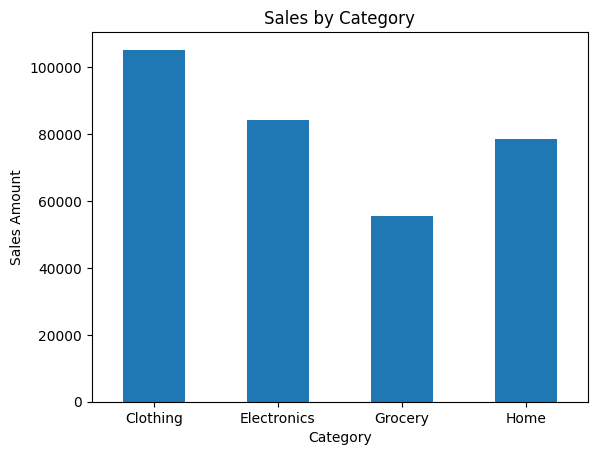

In [ ]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales Amount')
plt.xticks(rotation=0)
plt.show()

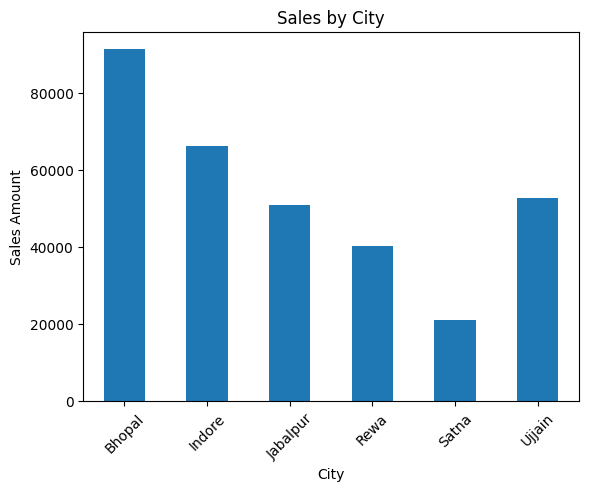

In [ ]:
city_sales.plot(kind='bar')

plt.title('Sales by City')
plt.xlabel('City')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
channel_sales

,sales_amount
sales_channel,
Offline,117523.25
Online,205475.00


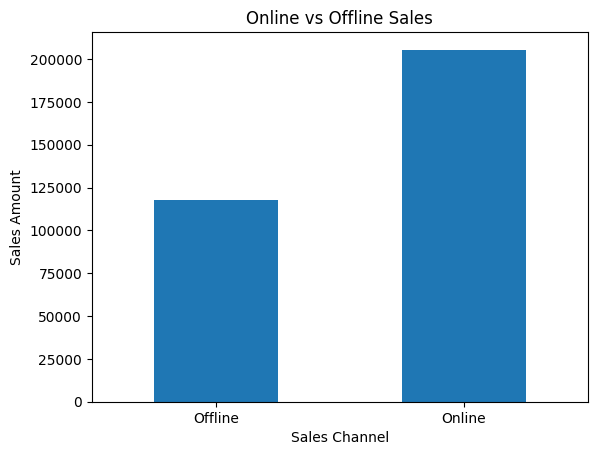

In [ ]:
channel_sales.plot(kind='bar')

plt.title('Online vs Offline Sales')
plt.xlabel('Sales Channel')
plt.ylabel('Sales Amount')
plt.xticks(rotation=0)
plt.show()

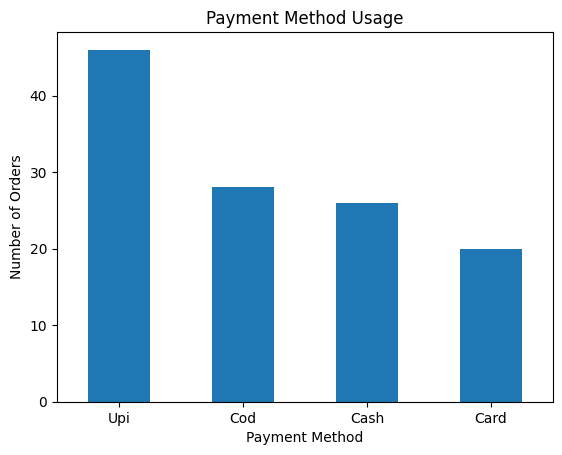

In [ ]:
payment_counts.plot(kind='bar')

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

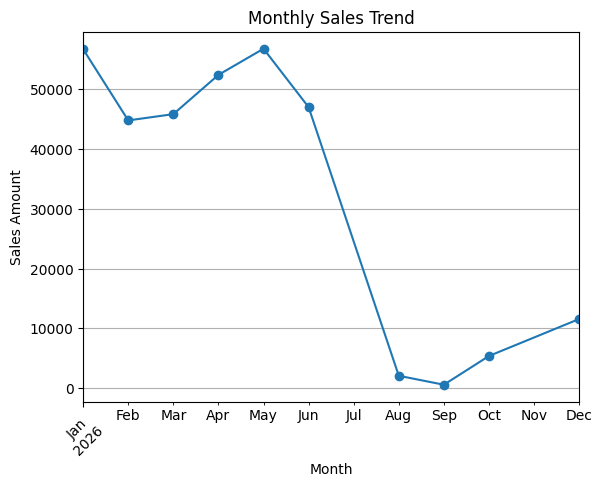

In [ ]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

हमारे current findings:

Metric	         Finding
Total Sales	    ₹322,998.25
Top Category	   Clothing
Top Product	     Jeans
Top City	       Bhopal
Top Channel     	Online
Most Used Payment	UPI
Best Sales Month	May

Step 6 में हम करेंगे:

1. Key Business Insights
→ सबसे important findings

2. Business Recommendations
→ Company को क्या करना चाहिए?

3. Final Conclusion
→ पूरे analysis का professional summary

और इसके बाद हमारा project लगभग portfolio-ready हो जाएगा.

Absolutely 👍 Let's start **STEP 6 — Business Insights & Conclusions**.

इस step में हम numbers को **business language** में convert करना सीखेंगे। यही चीज़ Data Analyst project को professional बनाती है।

# 🔹 STEP 6.1 — Key Business Insights

पहले हम अपने existing results से **5 major insights** निकालेंगे।

### Insight 1 — Category Performance

**Clothing** is the highest-performing category, generating **₹105,180** in sales.

**Business meaning:** Clothing is currently the strongest revenue contributor among the four categories.

---

### Insight 2 — Product Performance

**Jeans** is the highest-revenue product, generating **₹59,262.50**.

**Business meaning:** Jeans is a particularly strong product and may deserve more inventory or promotional attention.

---

### Insight 3 — City Performance

**Bhopal** generated the highest sales at **₹91,412.25**.

**Business meaning:** Bhopal is the strongest-performing market in this dataset.

---

### Insight 4 — Sales Channel

**Online sales = ₹205,475**, compared with **₹117,523.25** offline.

**Business meaning:** The online channel is significantly stronger and may deserve greater focus.

---

### Insight 5 — Payment Preference

**UPI was used in 46 out of 120 orders**, making it the most-used payment method
## 🧠 Important Data Analyst Skill

Notice what we're doing:

**Raw Data → Calculation → Analysis → Insight → Business Meaning**

For example:

```text
Raw Data
   ↓
Sales Amount
   ↓
Group by City
   ↓
Bhopal = ₹91,412.25
   ↓
Bhopal is the strongest market
This is much more valuable than simply saying *"I created a chart."*